# EXPLORATORIO

# Criterio de Fidelidad

## Contexto

El criterio de fidelidad clásico está definido a partir del **handbook** de ALMA, usando la siguiente definición:
$$
\frac{|X|}{max(|X-Y|,0.7\cdot RMS(Y))}
$$
, siendo $X$: **cubo not noisy original** y $Y$: **cubo denoiseado**. El procedimiento se puede realizar tanto entre cubos como en momentos, generando un mapeo de fidelidad.

La problemática actual a combatir es que las imágenes denoiseadas no presentan una forma de calcular RMS. Por lo tanto, la ecuación definida por ALMA no es útil. Se verán distintas maneras de poder comparar una serie de imágenes, buscando la mejor para definir un criterio de fidelidad correcto y justo.

# 0. Importaciones y Configuración

In [212]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy import constants as const
import os

import sys

sys.path.append('../../src')

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data'

## 0.1. Definición de funciones

In [274]:
def fidelity_ALMA(X,Y,rms_Y):

    X_ref = np.abs(X)

    diff_X_Y = X_ref - np.abs(Y)
    rms_cube = (0.7 * rms_Y) * np.ones_like(Y)

    divisor = np.maximum(diff_X_Y, rms_cube)

    return X_ref / divisor


def fidelity_ALMA_no_rms(X,Y):

    X_ref = np.abs(X)

    diff_X_Y = X_ref - np.abs(Y)

    return X_ref / diff_X_Y

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

## 0.2. Elección Cubo a utilizar

In [171]:
CUBE_TYPE_DIR = 'mock_cubes'
CUBE_DIR = 'isolated_sub_AC5_N50_width1'

## 0.3. !! Sistema de guardado de cubos

In [ ]:
CUBE_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_5'
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))

hdu[0].data[:,0,:,:] = fidelity_cube_denoised

out_name = f'{CUBE_NAME}_fidelitycube.fits'
out_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, out_name)
hdu.writeto(out_path, overwrite=True, output_verify='fix')

# 1. Fidelidad en Cubos

## 1.1. Apertura Cubos

In [172]:
# CUBO DE REFERENCIA (NOT NOISY)
CUBE_NAME = 'isolated_sub_AC5_N50_width1_notnoisy_sub'
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube_ref = np.squeeze(hdu[0].data)
cube_ref = np.nan_to_num(cube_ref, nan=0.0)

# CUBO RUIDOSO
CUBE_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub'
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube_noisy = np.squeeze(hdu[0].data)
cube_noisy = np.nan_to_num(cube_noisy, nan=0.0)

# CUBO DENOISEADO
CUBE_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub_wavelets_iterative_soft_5'
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube_denoised = np.squeeze(hdu[0].data)
cube_denoised = np.nan_to_num(cube_denoised, nan=0.0)

## 1.2. Fidelidad ALMA

In [174]:
rms_denoised = 9.55e-5 / 3 # El valor corresponde al x_break del cubo denoised como propuesta de RMS.
print('RMS Denoised: ', rms_denoised)
rms_noisy = np.std(cube_noisy[1:35,:,:])
print('RMS Noisy: ', rms_noisy)

fidelity_ALMA_noisy = fidelity_ALMA(cube_ref, cube_noisy, rms_noisy)
fidelity_ALMA_denoised = fidelity_ALMA(cube_ref, cube_denoised, rms_denoised)

RMS Denoised:  3.183333333333333e-05
RMS Noisy:  0.000116285875


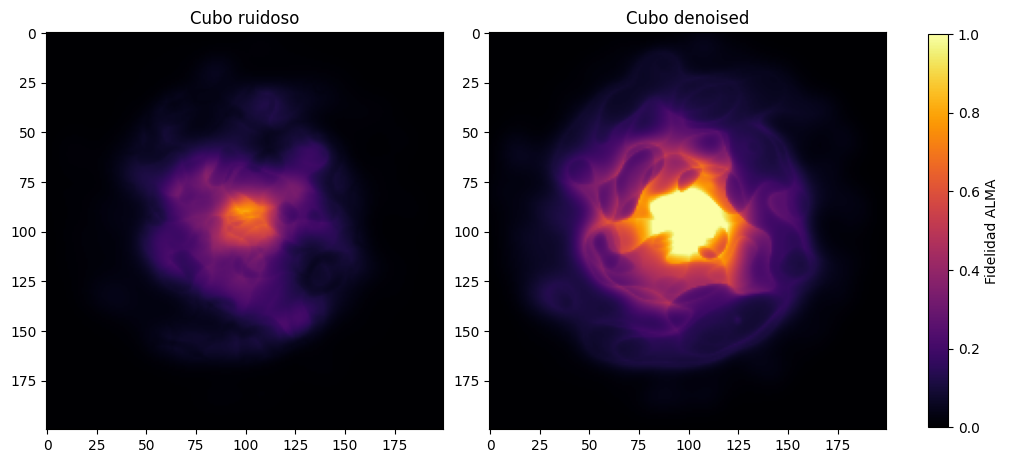

In [176]:
fidelity_ALMA_noisy_2d = np.mean(fidelity_ALMA_noisy, axis=0)
fidelity_ALMA_denoised_2d = np.mean(fidelity_ALMA_denoised, axis=0)

cmap = 'inferno'

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

im0 = ax[0].imshow(fidelity_ALMA_noisy_2d, cmap=cmap, vmin=0, vmax=1)
ax[0].set_title('Cubo ruidoso')

im1 = ax[1].imshow(fidelity_ALMA_denoised_2d, cmap=cmap, vmin=0, vmax=1)
ax[1].set_title('Cubo denoised')

fig.colorbar(im1, ax=ax, shrink=0.8, label='Fidelidad ALMA')
plt.show()



## 1.3. Chi Cuadrado

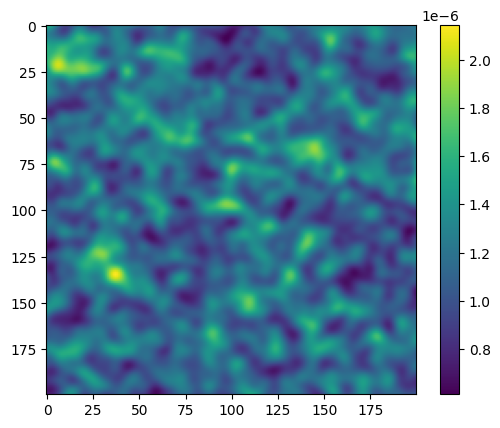

In [157]:
chi_cuadrado = ((cube_noisy - cube_ref)**2)
#chi_cuadrado[~np.isfinite(chi_cuadrado)] = np.nan
chi_cuadrado_2d = np.nansum(chi_cuadrado, axis=0)

plt.imshow(chi_cuadrado_2d)
plt.colorbar()
plt.show()

hdu[0].data[:,0,:,:] = chi_cuadrado

out_name = f'{CUBE_NAME}_chi_cuadrado.fits'
out_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, out_name)
hdu.writeto(out_path, overwrite=True, output_verify='fix')

# 2. Fidelidad en momentos

In [250]:
DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes/isolated_sub_AC5_N50_width1/moments'

## 2.1. Momento 0

### 2.1.1. Apertura Momentos 0

In [251]:
hdum = fits.open(os.path.join(DATA_DIR, 'noisy_moment0.fits'))
moment_0_noisy = np.squeeze(hdum[0].data)

hdum = fits.open(os.path.join(DATA_DIR, 'denoised_moment0.fits'))
moment_0_denoised = np.squeeze(hdum[0].data)

hdum = fits.open(os.path.join(DATA_DIR, 'notnoisy_moment0.fits'))
moment_0_ref = np.squeeze(hdum[0].data)

### 2.1.2. Visualización Momentos 0

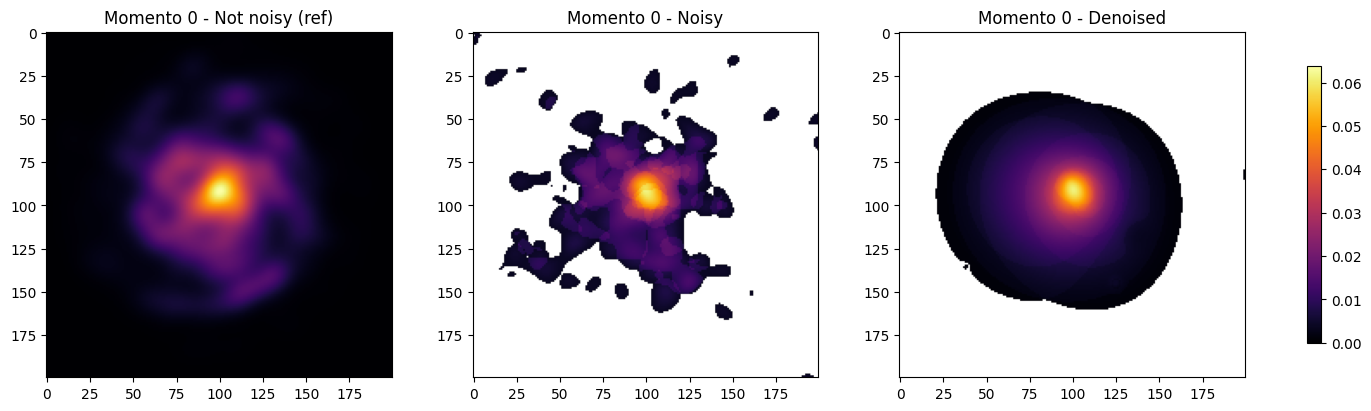

In [187]:

fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

vmin = min(moment_0_ref.min(), moment_0_noisy.min(), moment_0_denoised.min())
vmax = max(moment_0_ref.max(), moment_0_noisy.max(), moment_0_denoised.max())

im0 = ax[0].imshow(moment_0_ref, vmin=vmin, vmax=vmax, cmap='inferno')
ax[0].set_title('Momento 0 - Not noisy (ref)')

im1 = ax[1].imshow(moment_0_noisy, vmin=vmin, vmax=vmax, cmap='inferno')
ax[1].set_title('Momento 0 - Noisy')

im2 = ax[2].imshow(moment_0_denoised, vmin=vmin, vmax=vmax, cmap='inferno')
ax[2].set_title('Momento 0 - Denoised')

fig.colorbar(im2, ax=ax, shrink=0.8)
plt.show()


### 2.1.3. Cálculo RMSE global

In [238]:
moment_0_noisy_flat = np.nan_to_num(moment_0_noisy.flatten())
moment_0_denoised_flat = np.nan_to_num(moment_0_denoised.flatten())
moment_0_ref_flat = np.nan_to_num(moment_0_ref.flatten())


rmse_noisy_moment0 = rmse(moment_0_noisy_flat, moment_0_ref_flat)
rmse_denoised_moment0 = rmse(moment_0_denoised_flat, moment_0_ref_flat)

print(f'RMSE momento 0 (noisy    vs not noisy): {rmse_noisy_moment0:.6e}')
print(f'RMSE momento 0 (denoised vs not noisy): {rmse_denoised_moment0:.6e}')
print(f'Reducción del RMSE tras denoising: {(1 - rmse_denoised_moment0 / rmse_noisy_moment0) * 100:.2f} %')
print(f'Razón RMSE noisy / RMSE denoised:  {rmse_noisy_moment0 / rmse_denoised_moment0:.3f}')

RMSE momento 0 (noisy    vs not noisy): 4.316092e-03
RMSE momento 0 (denoised vs not noisy): 3.186750e-03
Reducción del RMSE tras denoising: 26.17 %
Razón RMSE noisy / RMSE denoised:  1.354


### 2.1.4. Mapeo diferencias al cuadrado

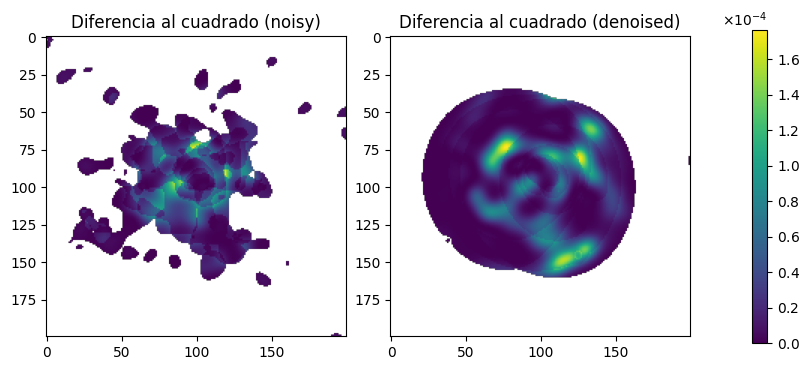

In [213]:
diff_moment0_noisy = (moment_0_noisy - moment_0_ref)**2
diff_moment0_denoised = (moment_0_denoised - moment_0_ref)**2

fig, ax = plt.subplots(1, 2, figsize=(8,4), constrained_layout=True)

im0 = ax[0].imshow(diff_moment0_noisy)
ax[0].set_title('Diferencia al cuadrado (noisy)')

im1 = ax[1].imshow(diff_moment0_denoised)
ax[1].set_title('Diferencia al cuadrado (denoised)')

formateador = ticker.ScalarFormatter(useMathText=True)
formateador.set_scientific(True)
formateador.set_powerlimits((0, 0)) # Fuerza la notación siempre

cbar = fig.colorbar(im1, ax=ax, shrink=0.8)
cbar.formatter = formateador
cbar.update_ticks()

plt.show()

## 2.2. Momento 1

### 2.2.1. Apertura Momentos 1

In [225]:
DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'
hdum = fits.open(os.path.join(DATA_DIR, 'noisy_moment1.fits'))
moment_1_noisy = np.squeeze(hdum[0].data)

hdum = fits.open(os.path.join(DATA_DIR, 'denoised_moment1.fits'))
moment_1_denoised = np.squeeze(hdum[0].data)

hdum = fits.open(os.path.join(DATA_DIR, 'notnoisy_moment1.fits'))
moment_1_ref = np.squeeze(hdum[0].data)

### 2.2.2. Visualización Momentos 1

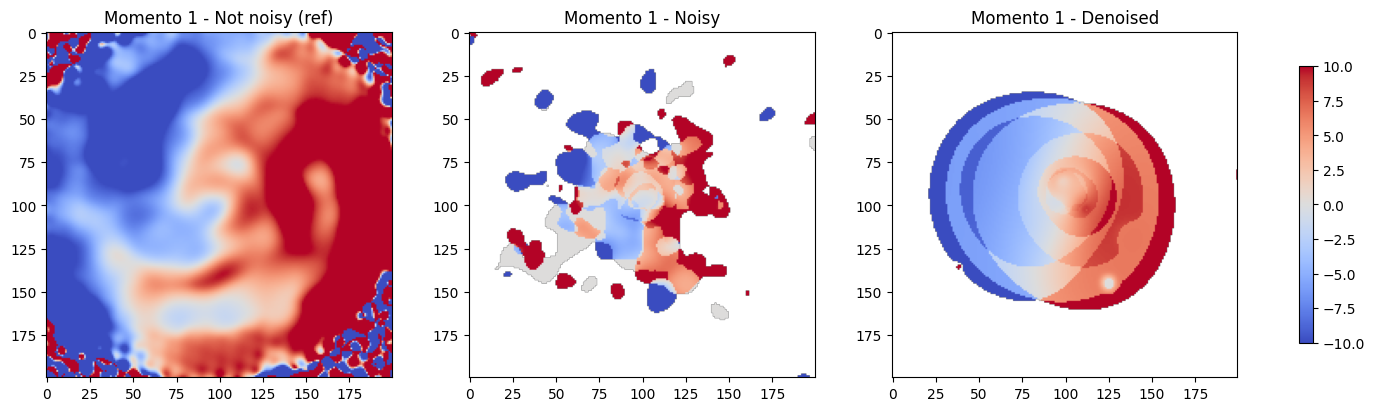

In [226]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

cmap = 'coolwarm'

im0 = ax[0].imshow(moment_1_ref, vmin=-10, vmax=10, cmap=cmap)
ax[0].set_title('Momento 1 - Not noisy (ref)')

im1 = ax[1].imshow(moment_1_noisy, vmin=-10, vmax=10, cmap=cmap)
ax[1].set_title('Momento 1 - Noisy')

im2 = ax[2].imshow(moment_1_denoised, vmin=-10, vmax=10, cmap=cmap)
ax[2].set_title('Momento 1 - Denoised')

formateador = ticker.ScalarFormatter(useMathText=True)
formateador.set_scientific(True)
formateador.set_powerlimits((0, 0)) # Fuerza la notación siempre

cbar = fig.colorbar(im1, ax=ax, shrink=0.8)

plt.show()


### 2.2.3. Cálculo RMSE global

In [237]:
moment_1_noisy_flat = np.nan_to_num(moment_1_noisy.flatten())
moment_1_denoised_flat = np.nan_to_num(moment_1_denoised.flatten())
moment_1_ref_flat = np.nan_to_num(moment_1_ref.flatten())


rmse_noisy_moment1 = rmse(moment_1_noisy_flat, moment_1_ref_flat)
rmse_denoised_moment1 = rmse(moment_1_denoised_flat, moment_1_ref_flat)

print(f'RMSE momento 1 (noisy    vs not noisy): {rmse_noisy_moment1:.6e}')
print(f'RMSE momento 1 (denoised vs not noisy): {rmse_denoised_moment1:.6e}')
print(f'Reducción del RMSE tras denoising: {(1 - rmse_denoised_moment1 / rmse_noisy_moment1) * 100:.2f} %')
print(f'Razón RMSE noisy / RMSE denoised:  {rmse_noisy_moment1 / rmse_denoised_moment1:.3f}')

RMSE momento 1 (noisy    vs not noisy): 3.341675e+02
RMSE momento 1 (denoised vs not noisy): 3.341050e+02
Reducción del RMSE tras denoising: 0.02 %
Razón RMSE noisy / RMSE denoised:  1.000


### 2.2.4. Mapeo diferencias al cuadrado

/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_24673/3841105590.py:12: UserWarning: Adding colorbar to a different Figure <Figure size 1400x400 with 4 Axes> than <Figure size 800x400 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im2, ax=ax, shrink=0.8)


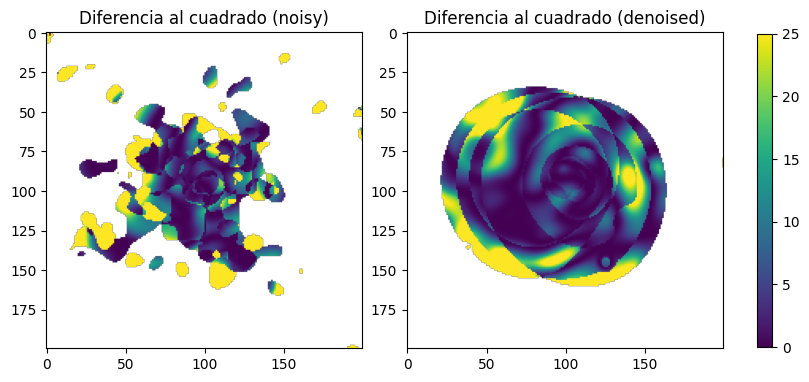

In [248]:
diff_moment1_noisy = (moment_1_noisy - moment_1_ref)**2
diff_moment1_denoised = (moment_1_denoised - moment_1_ref)**2

fig, ax = plt.subplots(1, 2, figsize=(8,4), constrained_layout=True)

im0 = ax[0].imshow(diff_moment1_noisy, vmin=0, vmax=50)
ax[0].set_title('Diferencia al cuadrado (noisy)')

im1 = ax[1].imshow(diff_moment1_denoised, vmin=0, vmax=50)
ax[1].set_title('Diferencia al cuadrado (denoised)')

cbar = fig.colorbar(im2, ax=ax, shrink=0.8)

plt.show()

## 2.3. Momento 2

### 2.3.1. Apertura Momentos 2

In [ ]:
hdum = fits.open(os.path.join(DATA_DIR, 'noisy_moment2.fits'))
moment_2_noisy = np.squeeze(hdum[0].data)

hdum = fits.open(os.path.join(DATA_DIR, 'denoised_moment2.fits'))
moment_2_denoised = np.squeeze(hdum[0].data)

hdum = fits.open(os.path.join(DATA_DIR, 'notnoisy_moment2.fits'))
moment_2_ref = np.squeeze(hdum[0].data)

### 2.3.2. Visualización Momentos 2

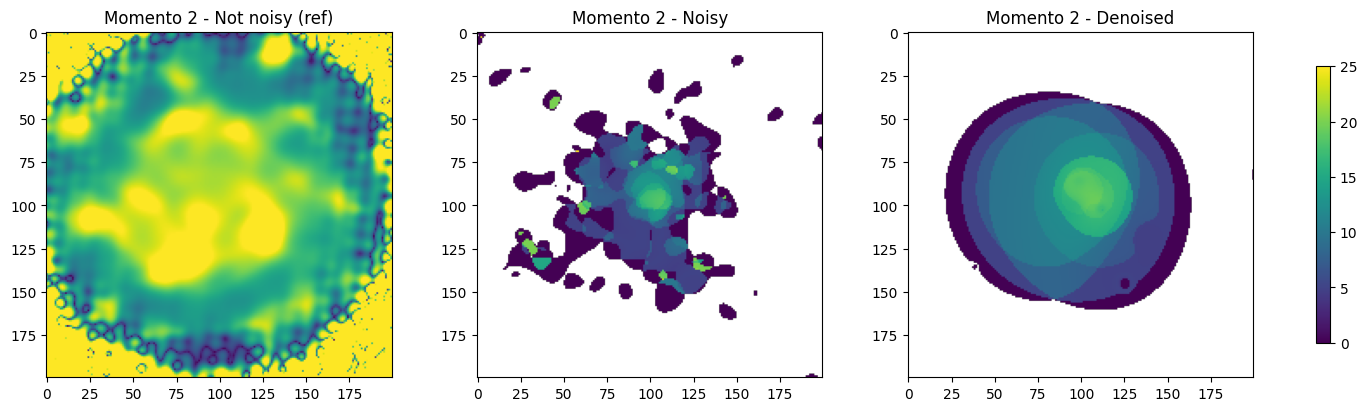

In [234]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

cmap = 'viridis'
vmin = 0
vmax =25

im0 = ax[0].imshow(moment_2_ref, vmin=vmin, vmax=vmax, cmap=cmap)
ax[0].set_title('Momento 2 - Not noisy (ref)')

im1 = ax[1].imshow(moment_2_noisy, vmin=vmin, vmax=vmax, cmap=cmap)
ax[1].set_title('Momento 2 - Noisy')

im2 = ax[2].imshow(moment_2_denoised, vmin=vmin, vmax=vmax, cmap=cmap)
ax[2].set_title('Momento 2 - Denoised')

fig.colorbar(im2, ax=ax, shrink=0.8)
plt.show()

### 2.3.3. Cálculo RMSE global

In [236]:
moment_2_noisy_flat = np.nan_to_num(moment_2_noisy.flatten())
moment_2_denoised_flat = np.nan_to_num(moment_2_denoised.flatten())
moment_2_ref_flat = np.nan_to_num(moment_2_ref.flatten())


rmse_noisy_moment2 = rmse(moment_2_noisy_flat, moment_2_ref_flat)
rmse_denoised_moment2 = rmse(moment_2_denoised_flat, moment_2_ref_flat)

print(f'RMSE momento 2 (noisy    vs not noisy): {rmse_noisy_moment2:.6e}')
print(f'RMSE momento 2 (denoised vs not noisy): {rmse_denoised_moment2:.6e}')
print(f'Reducción del RMSE tras denoising: {(1 - rmse_denoised_moment2 / rmse_noisy_moment2) * 100:.2f} %')
print(f'Razón RMSE noisy / RMSE denoised:  {rmse_noisy_moment2 / rmse_denoised_moment2:.3f}')

RMSE momento 2 (noisy    vs not noisy): 3.358280e+02
RMSE momento 2 (denoised vs not noisy): 3.357415e+02
Reducción del RMSE tras denoising: 0.03 %
Razón RMSE noisy / RMSE denoised:  1.000


### 2.3.4. Mapeo diferencias al cuadrado

/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_24673/3761184631.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 1400x400 with 4 Axes> than <Figure size 800x400 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im2, ax=ax, shrink=0.8)


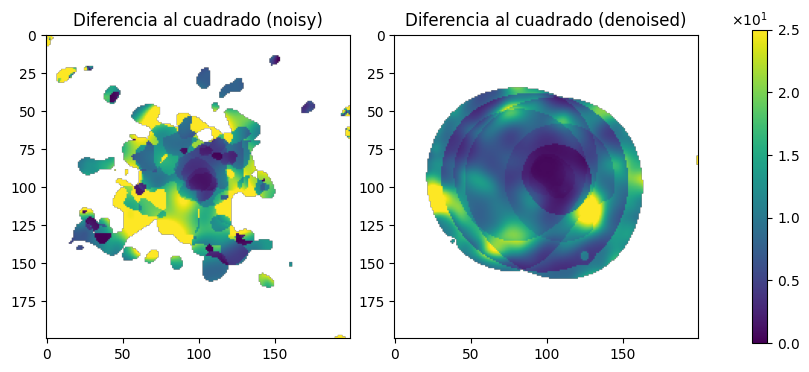

In [247]:
diff_moment2_noisy = (moment_2_noisy - moment_2_ref)**2
diff_moment2_denoised = (moment_2_denoised - moment_2_ref)**2

fig, ax = plt.subplots(1, 2, figsize=(8,4), constrained_layout=True)

im0 = ax[0].imshow(diff_moment2_noisy, vmin=0, vmax=500)
ax[0].set_title('Diferencia al cuadrado (noisy)')

im1 = ax[1].imshow(diff_moment2_denoised, vmin=0, vmax=500)
ax[1].set_title('Diferencia al cuadrado (denoised)')

formateador = ticker.ScalarFormatter(useMathText=True)
formateador.set_scientific(True)
formateador.set_powerlimits((0, 0)) # Fuerza la notación siempre

cbar = fig.colorbar(im2, ax=ax, shrink=0.8)
cbar.formatter = formateador
cbar.update_ticks()

plt.show()

# 3. Variación del RMSE en función del valor umbral en la máscara de corte

Vamos a testear como el RMSE cambia en función del valor umbral utilizado en la máscara de corte utilizada para los momentos.

## 3.1. Cubo Noisy

### 3.1.1. Apertura Momentos 0 

In [252]:
hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment0.fits'))
moment_0_noisy = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment0_double_threshold.fits'))
moment_0_noisy_double_threshold = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment0_half_threshold.fits'))
moment_0_noisy_half_threshold = np.squeeze(hdu[0].data)

### 3.1.2. Visualización Momentos 0

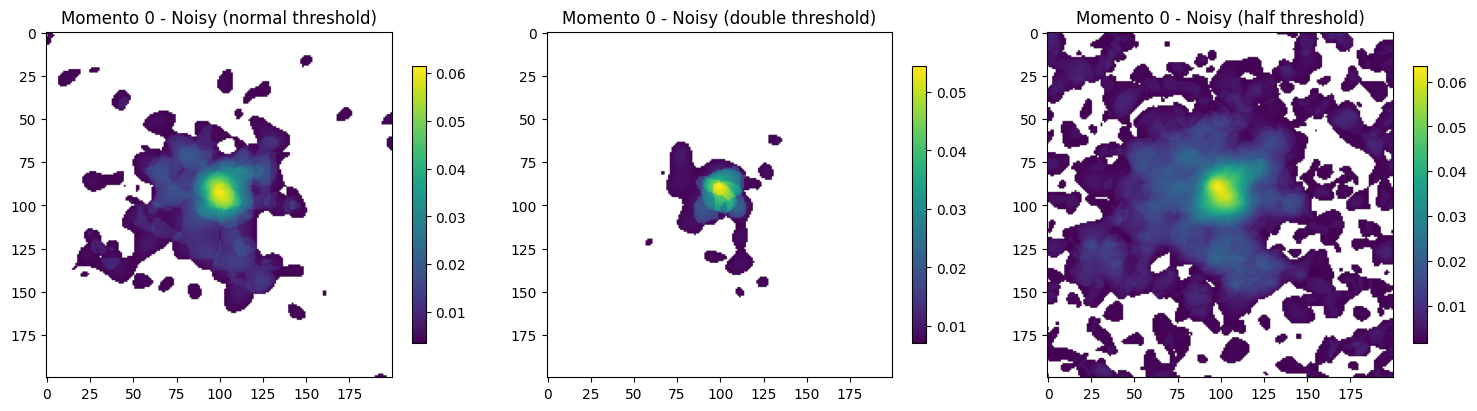

In [261]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
cmap = 'viridis'
arrays = [moment_0_noisy, moment_0_noisy_double_threshold, moment_0_noisy_half_threshold]
titles = ['Momento 0 - Noisy (normal threshold)',
          'Momento 0 - Noisy (double threshold)',
          'Momento 0 - Noisy (half threshold)']
for a, t, axi in zip(arrays, titles, ax):
    im = axi.imshow(a, cmap=cmap)
    axi.set_title(t)
    fig.colorbar(im, ax=axi, shrink=0.8)
plt.show()

### 3.1.3. Comparación de valores RMSE

In [276]:
moment_0_noisy_flat = np.nan_to_num(moment_0_noisy.flatten())
moment_0_noisy_double_threshold_flat = np.nan_to_num(moment_0_noisy_double_threshold.flatten())
moment_0_noisy_half_threshold_flat = np.nan_to_num(moment_0_noisy_half_threshold.flatten())

rmse_noisy_moment0 = rmse(moment_0_noisy_flat, moment_0_ref_flat)
rmse_noisy_moment0_double_threshold = rmse(moment_0_noisy_double_threshold_flat, moment_0_ref_flat)
rmse_noisy_moment0_half_threshold = rmse(moment_0_noisy_half_threshold_flat, moment_0_ref_flat)

print(rmse_noisy_moment0_double_threshold)
print(rmse_noisy_moment0)
print(rmse_noisy_moment0_half_threshold)


0.0072929743
0.004316092
0.0032571047


In [277]:
hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment1.fits'))
moment_1_noisy = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment1_double_threshold.fits'))
moment_1_noisy_double_threshold = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment1_half_threshold.fits'))
moment_1_noisy_half_threshold = np.squeeze(hdu[0].data)

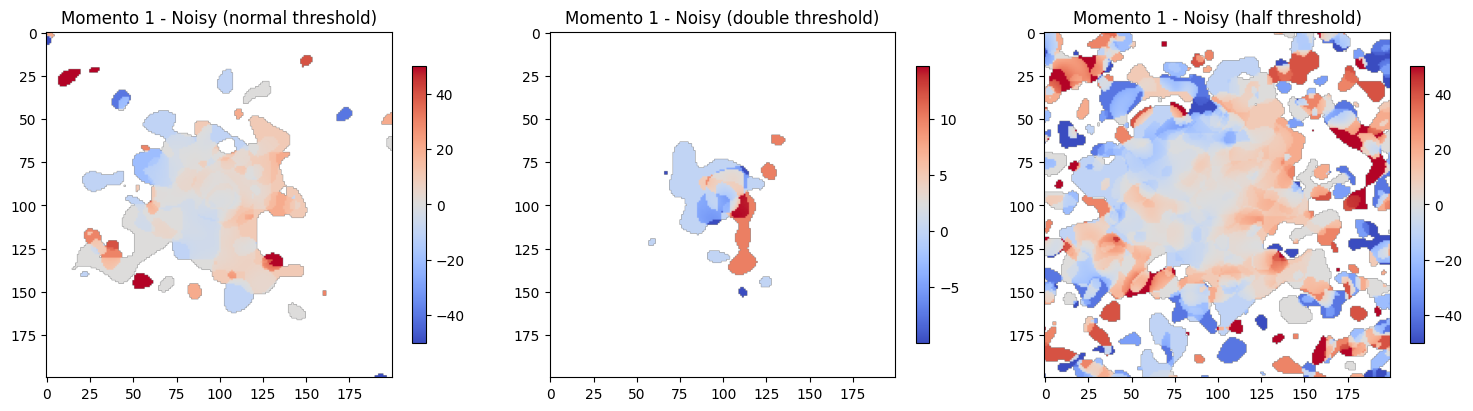

In [279]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
cmap = 'coolwarm'
arrays = [moment_1_noisy, moment_1_noisy_double_threshold, moment_1_noisy_half_threshold]
titles = ['Momento 1 - Noisy (normal threshold)',
          'Momento 1 - Noisy (double threshold)',
          'Momento 1 - Noisy (half threshold)']
for a, t, axi in zip(arrays, titles, ax):
    im = axi.imshow(a, cmap=cmap)
    axi.set_title(t)
    fig.colorbar(im, ax=axi, shrink=0.8)
plt.show()

In [280]:
moment_1_noisy_flat = np.nan_to_num(moment_1_noisy.flatten())
moment_1_noisy_double_threshold_flat = np.nan_to_num(moment_1_noisy_double_threshold.flatten())
moment_1_noisy_half_threshold_flat = np.nan_to_num(moment_1_noisy_half_threshold.flatten())

rmse_noisy_moment1 = rmse(moment_1_noisy_flat, moment_1_ref_flat)
rmse_noisy_moment1_double_threshold = rmse(moment_1_noisy_double_threshold_flat, moment_1_ref_flat)
rmse_noisy_moment1_half_threshold = rmse(moment_1_noisy_half_threshold_flat, moment_1_ref_flat)

print(rmse_noisy_moment1_double_threshold)
print(rmse_noisy_moment1)
print(rmse_noisy_moment1_half_threshold)

334.12674
334.16754
334.51138


In [281]:
hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment2.fits'))
moment_2_noisy = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment2_double_threshold.fits'))
moment_2_noisy_double_threshold = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'noisy_moment2_half_threshold.fits'))
moment_2_noisy_half_threshold = np.squeeze(hdu[0].data)

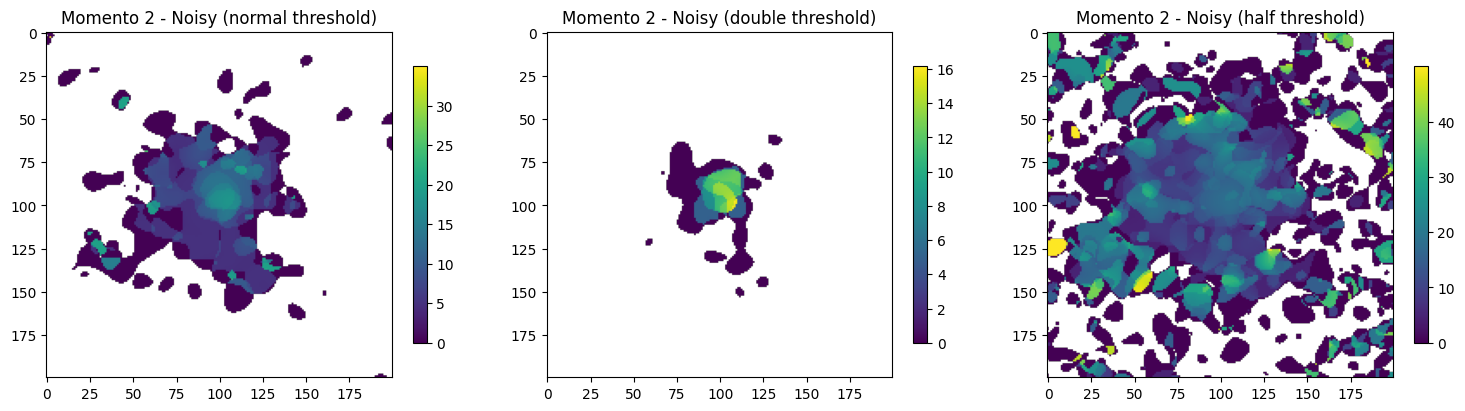

In [282]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
cmap = 'viridis'
arrays = [moment_2_noisy, moment_2_noisy_double_threshold, moment_2_noisy_half_threshold]
titles = ['Momento 2 - Noisy (normal threshold)',
          'Momento 2 - Noisy (double threshold)',
          'Momento 2 - Noisy (half threshold)']
for a, t, axi in zip(arrays, titles, ax):
    im = axi.imshow(a, cmap=cmap)
    axi.set_title(t)
    fig.colorbar(im, ax=axi, shrink=0.8)
plt.show()

In [283]:
moment_2_noisy_flat = np.nan_to_num(moment_2_noisy.flatten())
moment_2_noisy_double_threshold_flat = np.nan_to_num(moment_2_noisy_double_threshold.flatten())
moment_2_noisy_half_threshold_flat = np.nan_to_num(moment_2_noisy_half_threshold.flatten())

rmse_noisy_moment2 = rmse(moment_2_noisy_flat, moment_2_ref_flat)
rmse_noisy_moment2_double_threshold = rmse(moment_2_noisy_double_threshold_flat, moment_2_ref_flat)
rmse_noisy_moment2_half_threshold = rmse(moment_2_noisy_half_threshold_flat, moment_2_ref_flat)

print(rmse_noisy_moment2_double_threshold)
print(rmse_noisy_moment2)
print(rmse_noisy_moment2_half_threshold)

335.8686
335.82803
335.26913


## 3.2. Cubo Denoised

### 3.2.1. Apertura Momentos 0

In [265]:
hdu = fits.open(os.path.join(DATA_DIR, 'denoised_moment0.fits'))
moment_0_denoised = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'denoised_moment0_double_threshold.fits'))
moment_0_denoised_double_threshold = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'denoised_moment0_half_threshold.fits'))
moment_0_denoised_half_threshold = np.squeeze(hdu[0].data)

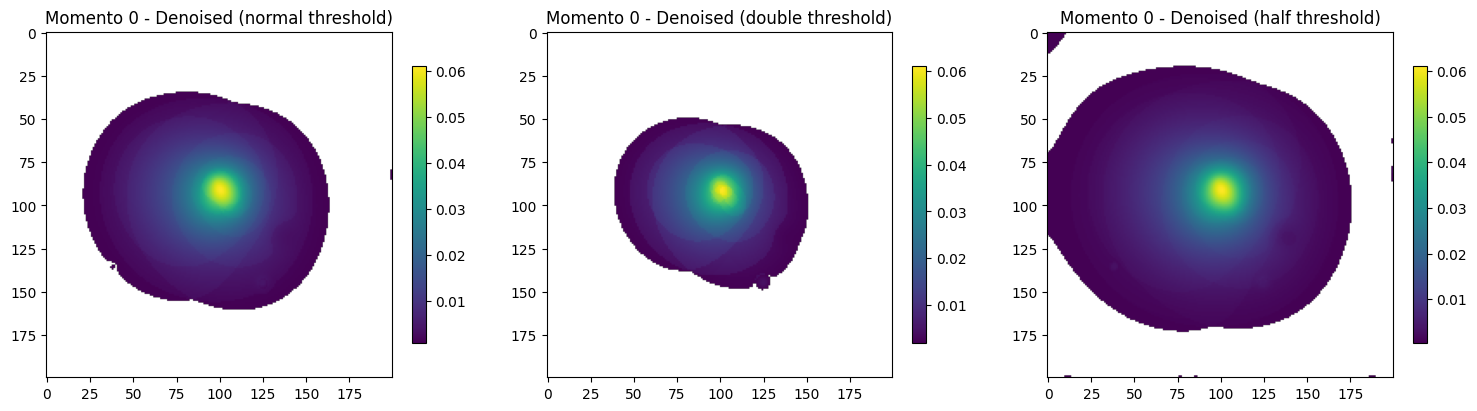

In [266]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
cmap = 'viridis'
arrays = [moment_0_denoised, moment_0_denoised_double_threshold, moment_0_denoised_half_threshold]
titles = ['Momento 0 - Denoised (normal threshold)',
          'Momento 0 - Denoised (double threshold)',
          'Momento 0 - Denoised (half threshold)']
for a, t, axi in zip(arrays, titles, ax):
    im = axi.imshow(a, cmap=cmap)
    axi.set_title(t)
    fig.colorbar(im, ax=axi, shrink=0.8)
plt.show()

### 3.2.3. Comparación de valores RMSE

In [267]:
moment_0_denoised_flat = np.nan_to_num(moment_0_denoised.flatten())
moment_0_denoised_double_threshold_flat = np.nan_to_num(moment_0_denoised_double_threshold.flatten())
moment_0_denoised_half_threshold_flat = np.nan_to_num(moment_0_denoised_half_threshold.flatten())


rmse_denoised_moment0 = rmse(moment_0_denoised_flat, moment_0_ref_flat)
rmse_denoised_moment0_double_threshold = rmse(moment_0_denoised_double_threshold_flat, moment_0_ref_flat)
rmse_denoised_moment0_half_threshold = rmse(moment_0_denoised_half_threshold_flat, moment_0_ref_flat)

print(rmse_denoised_moment0_double_threshold)
print(rmse_denoised_moment0)
print(rmse_denoised_moment0_half_threshold)

0.0040987977
0.00318675
0.0027759334


In [284]:
hdu = fits.open(os.path.join(DATA_DIR, 'denoised_moment1.fits'))
moment_1_denoised = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'denoised_moment1_double_threshold.fits'))
moment_1_denoised_double_threshold = np.squeeze(hdu[0].data)

hdu = fits.open(os.path.join(DATA_DIR, 'denoised_moment1_half_threshold.fits'))
moment_1_denoised_half_threshold = np.squeeze(hdu[0].data)

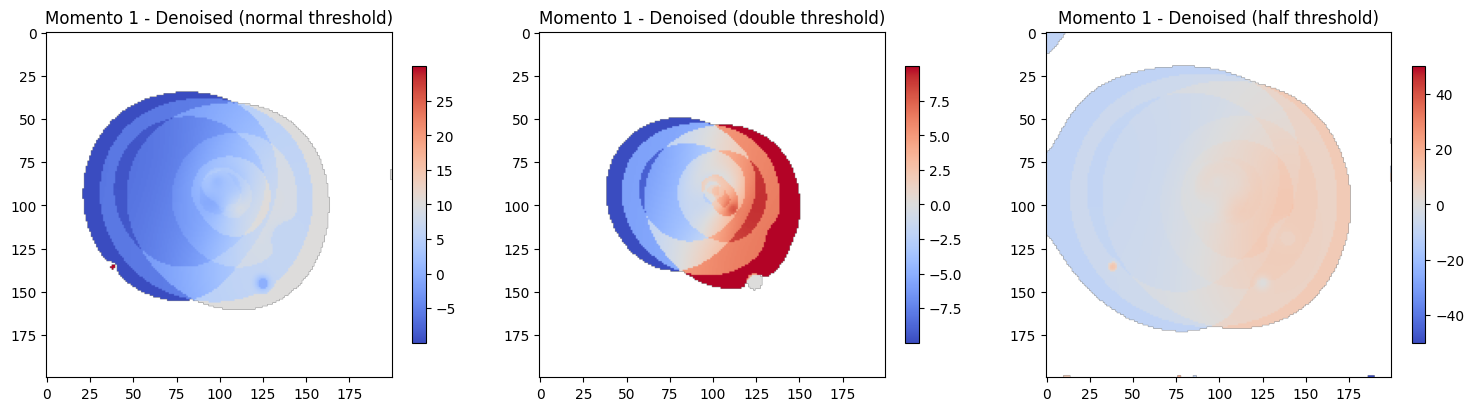

In [286]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
cmap = 'coolwarm'
arrays = [moment_1_denoised, moment_1_denoised_double_threshold, moment_1_denoised_half_threshold]
titles = ['Momento 1 - Denoised (normal threshold)',
          'Momento 1 - Denoised (double threshold)',
          'Momento 1 - Denoised (half threshold)']
for a, t, axi in zip(arrays, titles, ax):
    im = axi.imshow(a, cmap=cmap)
    axi.set_title(t)
    fig.colorbar(im, ax=axi, shrink=0.8)
plt.show()

In [290]:
moment_1_denoised_flat = np.nan_to_num(moment_1_denoised.flatten())
moment_1_denoised_double_threshold_flat = np.nan_to_num(moment_1_denoised_double_threshold.flatten())
moment_1_denoised_half_threshold_flat = np.nan_to_num(moment_1_denoised_half_threshold.flatten())


rmse_denoised_moment1 = rmse(moment_1_denoised_flat, moment_1_ref_flat)
rmse_denoised_moment1_double_threshold = rmse(moment_1_denoised_double_threshold_flat, moment_1_ref_flat)
rmse_denoised_moment1_half_threshold = rmse(moment_1_denoised_half_threshold_flat, moment_1_ref_flat)

print(rmse_denoised_moment1_double_threshold)
print(rmse_denoised_moment1)
print(rmse_denoised_moment1_half_threshold)


334.1128
334.105
334.09454
